#TOURNAMENT BASED MODEL

##Setup

In [1]:
# set things up
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
from google.colab import files
from collections import defaultdict
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# upload the "all_years.xlsx" file
uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


##Hyper Parameter Selection

This selects the hyper parameters based on the test year being 2023. You can change this for testing on other years based on changing the years list defined in "Hyperparameter Selection Execution".

###Hyperparameter Selection Setup

In [ ]:
# Monolith setup

# ============================================================
# 1. BUILD TEAM-LEVEL SEASON STATS
# ============================================================

def build_team_stats(df):
    home_cols = [c for c in df.columns if c.startswith("home_")]
    away_cols = [c for c in df.columns if c.startswith("away_")]

    home_rename = {c: c.replace("home_", "") for c in home_cols}
    away_rename = {c: c.replace("away_", "") for c in away_cols}

    # Home stats
    home_df = df[["season"] + home_cols].rename(columns=home_rename)
    home_df["team"] = df["home_short_display_name"]

    # Away stats
    away_df = df[["season"] + away_cols].rename(columns=away_rename)
    away_df["team"] = df["away_short_display_name"]


    # Combine
    team_stats = pd.concat([home_df, away_df], ignore_index=True)

    # Average across season
    team_stats = team_stats.groupby(["season", "team"], as_index=False).mean(numeric_only=True)

    return team_stats

# ============================================================
# 2. BUILD PREDICT_FN
# ============================================================

def make_predict_fn(model, team_stats, feature_cols):
    def predict_fn(home_team, away_team, season):
        home_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == home_team)]
        away_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == away_team)]

        home_seed = int(home_row['seed'].iloc[0])
        away_seed = int(away_row['seed'].iloc[0])

        if home_seed > away_seed:
          tmp = home_row
          home_row = away_row
          away_row = tmp

        if home_row.empty or away_row.empty:
            raise ValueError(f"No stats found for home:{home_team} or away:{away_team} in season {season}")

        home_stats = home_row.drop(columns=["season","team"]).iloc[0].add_prefix("home_")
        away_stats = away_row.drop(columns=["season","team"]).iloc[0].add_prefix("away_")

        # Combine features
        row = pd.concat([home_stats, away_stats]).to_frame().T

        # Add season back if model expects it
        if "season" in model.feature_names_in_:
            row["season"] = season

        # Ensure correct order
        row = row[model.feature_names_in_]

        pred = model.predict(row)[0]

        home_name = str(home_row["team"].iloc[0])
        away_name = str(away_row["team"].iloc[0])
        #print(f"{home_name} vs {away_name} ||", f"{away_name} wins" if pred == 1 else f"{home_name} wins")

        return home_name if pred == 0 else away_name

    return predict_fn


# ============================================================
# 3. BUILD AUTOMATIC BRACKET
# ============================================================

def build_bracket(df):
    """
    df must have columns: season, home_short_display_name, away_short_display_name, home_score, away_score
    Returns dict: {season: {"games_df", "incoming", "next"}}
    """
    df = df.copy().reset_index(drop=True)
    df["game_id"] = df.index.astype(int)

    results = {}

    for season, g in df.groupby("season"):
        g = g.copy().reset_index(drop=True)
        g["winner"] = g.apply(lambda r: r["home_short_display_name"] if r["home_score"]>r["away_score"] else r["away_short_display_name"], axis=1)
        g["loser"]  = g.apply(lambda r: r["away_short_display_name"] if r["home_score"]>r["away_score"] else r["home_short_display_name"], axis=1)

        # Count wins per team
        wins = g["winner"].value_counts().to_dict()
        get_wins = lambda t: wins.get(t,0)

        # Infer round = min(#wins of the two teams)+1
        # STEP 1 — Base round using win-count logic
        g["round"] = g.apply(
            lambda r: min(
                get_wins(r["home_short_display_name"]),
                get_wins(r["away_short_display_name"])
            ) + 1,
            axis=1
        )

        # STEP 2 — Explicit First Four override (round = 0)
        def is_first_four(row):
            return (
                row["home_seed"] == row["away_seed"] and
                row["home_seed"] in [11, 16]
            )

        g.loc[g.apply(is_first_four, axis=1), "round"] = 0
        #g["round"] = g.apply(lambda r: min(get_wins(r["home_short_display_name"]), get_wins(r["away_short_display_name"])) + 1, axis=1)

        # Build game linkages
        incoming_map = defaultdict(list)
        next_map = defaultdict(list)
        participants = {row["game_id"]:(row["home_short_display_name"],row["away_short_display_name"]) for _,row in g.iterrows()}
        round_lookup = defaultdict(list)
        for _,row in g.iterrows():
            round_lookup[row["round"]].append(row["game_id"])

        for _, row in g.iterrows():
            gid = row["game_id"]
            winner = row["winner"]
            curr_round = row["round"]
            next_round = curr_round + 1
            for cand_gid in round_lookup.get(next_round, []):
                h,a = participants[cand_gid]
                if winner==h or winner==a:
                    next_map[gid].append(cand_gid)
                    incoming_map[cand_gid].append(gid)

        results[season] = {"games_df": g, "incoming": dict(incoming_map), "next": dict(next_map)}

    return results

# ============================================================
# 4. SIMULATE TOURNAMENT FROM BRACKET
# ============================================================

def simulate_with_model(season_struct, season, predict_fn):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        #print("=======================================")
        #print(f"Round {r}:")
        #print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = predict_fn(t1,t2,season)
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = predict_fn(team1,team2,season)
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = predict_fn(t1,t2,season)
                teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion

def build_with_data(season_struct, season):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        #print("=======================================")
        #print(f"Round {r}:")
        #print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            #print(F"LOOK HERE: {row["winner"]}")
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = row["winner"]
                #print(pred_winner[gid])
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = row["winner"]
                    #print(pred_winner[gid])
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = row["winner"]
                    #print(pred_winner[gid])
                teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion

###Hyperparameter Selection Execution

This works by going to the replacement area and selecting the algorithm you want to do hyperparameter selection for. Then copy and paste the code into the replacement area, remove the triple quotes, adjust variable names as needed, and run it.

In [ ]:
# Monolith

# load in the df
df = pd.read_excel("all_years.xlsx")

# process the df
bracket_df = df[~(
    (df["home_seed"] == df["away_seed"]) &
    (df["home_seed"].isin([11, 16])) &
    (df["date"].astype(str).str.contains("-03-"))
)]

df = df.drop(columns=["game_id","date"])
bracket_df = bracket_df.drop(columns=["game_id","date"])
bracket_df = bracket_df.fillna(bracket_df.select_dtypes(include="number").mean())

years = list(range(2002, 2020)) + [2021, 2022]

valid_stats = {}

for test_year in years:
    # Setup the training data

    X_train = df[df['season'] != test_year].drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
    X_train_mean = X_train.fillna(X_train.mean())
    y_train = df[df['season'] != test_year]['underdog_winner']

    y2023 = df.query(f"season == {test_year}")
    X_test = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
    X_test_mean = X_test.fillna(X_test.mean())
    y_test = y2023['underdog_winner']

    # Build predicted bracket
      # 1. Build team stats
    team_stats = build_team_stats(bracket_df).drop(columns=['score'])

      # 2. Define feature columns (home_*, away_*)
    feature_cols = [c for c in bracket_df.columns if c.startswith("home_") or c.startswith("away_")]
    feature_cols = [c for c in feature_cols if c not in [
        "home_score", "away_score", "home_short_display_name", "away_short_display_name"
    ]]

# START REPLACEMENT AREA
# RF -  ================================================================================

    t_estim = [100, 200]
    t_min_samples_split = [10, 20, 50, 75, 100]
    t_min_samples_leaf = [5, 10, 20, 30, 50]

    pairs = []

    Anth = 0
    models = len(list(product(t_estim, t_min_samples_split, t_min_samples_leaf)))

    for e, r, b in product(t_estim, t_min_samples_split, t_min_samples_leaf):
        #train classifier
        clf = RandomForestClassifier(n_estimators=e, min_samples_split=r, min_samples_leaf=b, max_depth=None, class_weight="balanced_subsample", random_state=72)
        clf.fit(X_train_mean, y_train)

# END REPLACEMENT AREA

          # 3. Build predict_fn
        predict_fn_model = make_predict_fn(clf, team_stats, feature_cols)

          # 4. Build bracket
        brackets = build_bracket(bracket_df)

          # 5. Simulate
        preds, tbr, champ = simulate_with_model(brackets[test_year], test_year, predict_fn_model)
        #print("Champion:", champ)

        # Build test bracket
        test_bracket_df = bracket_df.query(f"season == {test_year}")

        test_bracket = build_bracket(test_bracket_df)[test_year]
        test_preds, test_tbr, test_champ = build_with_data(test_bracket, test_year)

        # Output tourney level accuracy
        wrong = 0
        total = 0

        for idx in range(2, len(test_tbr)+2):
          rd = tbr[idx]
          rd_test = test_tbr[idx]

          for team in rd:
            if team not in rd_test:
              wrong += 1
            total += 1
          #print((total - wrong), total)
          #print((total-wrong)/total)

        final_acc = (total - wrong)/total
        pairs.append(((e, r, b), final_acc, test_year))

        print(test_year, (e, r, b), final_acc)

        valid_stats[(e, r, b, test_year)] = final_acc

        Anth += 1
        print(f"finished {Anth}/{models}")


# OTHER REPLACEMENTS

  # MLP ==============================================================================================
'''
    test_tol = [.001, .0001, .00001]
    test_layers = [(4,), (8,), (16,), (32,), (64,), (128,), (256,)]
    test_iter = [500]

    pairs = []

    Anth = 0
    models = len(list(product(test_tol, test_layers, test_iter)))

    for tol, layer, iteration in product(test_tol, test_layers, test_iter):
        #train classifier
        clf = MLPClassifier(hidden_layer_sizes=layer, max_iter=iteration, tol=tol, random_state=72)
        clf.fit(X_train_mean, y_train)
'''
# LR - ===========================================================
'''
    regs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
    pairs = []

    Anth = 0
    models = len(regs)

    for reg in regs:
        clf = LogisticRegression(solver='liblinear', max_iter=1000, C=reg)
        clf.fit(X_train_mean, y_train)
'''
# - DT ================================================================================
'''
    t_max_depth = [None, 5, 10, 15, 20]
    t_min_samples_split = [2, 5, 10, 20, 50]
    t_min_samples_leaf = [1, 2, 5, 10, 20]

    pairs = []

    Anth = 0
    models = len(list(product(t_max_depth, t_min_samples_split, t_min_samples_leaf)))

    for md, ms, ml in product(t_max_depth, t_min_samples_split, t_min_samples_leaf):
        #train classifier
        clf = DecisionTreeClassifier(max_depth=md, min_samples_split=ms, min_samples_leaf=ml, random_state=72)
        clf.fit(X_train_mean, y_train)
'''
# Ada -  ================================================================================
'''
    t_estim = [25, 100, 200]
    t_rate = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
    t_base = [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2),
        DecisionTreeClassifier(max_depth=3),
    ]


    pairs = []

    Anth = 0
    models = len(list(product(t_estim, t_rate, t_base)))

    for e, r, b in product(t_estim, t_rate, t_base):
        #train classifier
        clf = AdaBoostClassifier(n_estimators=e, learning_rate=r, estimator=b, random_state=72)
        clf.fit(X_train_mean, y_train)
'''

# RF -  ================================================================================
'''
    t_estim = [100, 200]
    t_min_samples_split = [10, 20, 50, 75, 100]
    t_min_samples_leaf = [5, 10, 20, 30, 50]

    pairs = []

    Anth = 0
    models = len(list(product(t_estim, t_min_samples_split, t_min_samples_leaf)))

    for e, r, b in product(t_estim, t_min_samples_split, t_min_samples_leaf):
        #train classifier
        clf = RandomForestClassifier(n_estimators=e, min_samples_split=r, min_samples_leaf=b, max_depth=None, class_weight="balanced_subsample", random_state=72)
        clf.fit(X_train_mean, y_train)
'''

2002 (100, 10, 5) 0.4838709677419355
finished 1/50
2002 (100, 10, 10) 0.5161290322580645
finished 2/50
2002 (100, 10, 20) 0.5161290322580645
finished 3/50
2002 (100, 10, 30) 0.6451612903225806
finished 4/50
2002 (100, 10, 50) 0.5483870967741935
finished 5/50
2002 (100, 20, 5) 0.5483870967741935
finished 6/50
2002 (100, 20, 10) 0.5161290322580645
finished 7/50
2002 (100, 20, 20) 0.5161290322580645
finished 8/50
2002 (100, 20, 30) 0.6451612903225806
finished 9/50
2002 (100, 20, 50) 0.5483870967741935
finished 10/50
2002 (100, 50, 5) 0.5161290322580645
finished 11/50
2002 (100, 50, 10) 0.5806451612903226
finished 12/50
2002 (100, 50, 20) 0.5806451612903226
finished 13/50
2002 (100, 50, 30) 0.6451612903225806
finished 14/50
2002 (100, 50, 50) 0.5483870967741935
finished 15/50
2002 (100, 75, 5) 0.5483870967741935
finished 16/50
2002 (100, 75, 10) 0.6451612903225806
finished 17/50
2002 (100, 75, 20) 0.5161290322580645
finished 18/50
2002 (100, 75, 30) 0.5806451612903226
finished 19/50
2002 (

'\n    t_estim = [25, 100, 200]\n    t_rate = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]\n    t_base = [\n        DecisionTreeClassifier(max_depth=1),\n        DecisionTreeClassifier(max_depth=2),\n        DecisionTreeClassifier(max_depth=3),\n    ]\n\n\n    pairs = []\n\n    Anth = 0\n    models = len(list(product(t_estim, t_rate, t_base)))\n\n    for e, r, b in product(t_estim, t_rate, t_base):\n        #train classifier\n        clf = AdaBoostClassifier(n_estimators=e, learning_rate=r, estimator=b, random_state=72)\n        clf.fit(X_train_mean, y_train)\n'

In [ ]:
print(valid_stats)

{(100, 10, 5, 2002): 0.4838709677419355, (100, 10, 10, 2002): 0.5161290322580645, (100, 10, 20, 2002): 0.5161290322580645, (100, 10, 30, 2002): 0.6451612903225806, (100, 10, 50, 2002): 0.5483870967741935, (100, 20, 5, 2002): 0.5483870967741935, (100, 20, 10, 2002): 0.5161290322580645, (100, 20, 20, 2002): 0.5161290322580645, (100, 20, 30, 2002): 0.6451612903225806, (100, 20, 50, 2002): 0.5483870967741935, (100, 50, 5, 2002): 0.5161290322580645, (100, 50, 10, 2002): 0.5806451612903226, (100, 50, 20, 2002): 0.5806451612903226, (100, 50, 30, 2002): 0.6451612903225806, (100, 50, 50, 2002): 0.5483870967741935, (100, 75, 5, 2002): 0.5483870967741935, (100, 75, 10, 2002): 0.6451612903225806, (100, 75, 20, 2002): 0.5161290322580645, (100, 75, 30, 2002): 0.5806451612903226, (100, 75, 50, 2002): 0.5483870967741935, (100, 100, 5, 2002): 0.5483870967741935, (100, 100, 10, 2002): 0.6129032258064516, (100, 100, 20, 2002): 0.6129032258064516, (100, 100, 30, 2002): 0.6129032258064516, (100, 100, 50, 2

In [ ]:
valid_eval = defaultdict(list)

for k, v in valid_stats.items():
  valid_eval[(k[0],k[1],str(k[2]))].append(v)

print(valid_eval)

defaultdict(<class 'list'>, {(100, 10, '5'): [0.4838709677419355, 0.5483870967741935, 0.5161290322580645, 0.5161290322580645, 0.5161290322580645, 0.5666666666666667, 0.7096774193548387, 0.6451612903225806, 0.41935483870967744, 0.4375, 0.78125, 0.6451612903225806, 0.5, 0.6774193548387096, 0.6774193548387096, 0.6129032258064516, 0.3870967741935484, 0.6129032258064516, 0.6774193548387096, 0.46875], (100, 10, '10'): [0.5161290322580645, 0.5806451612903226, 0.5806451612903226, 0.5806451612903226, 0.6129032258064516, 0.6333333333333333, 0.7096774193548387, 0.5806451612903226, 0.41935483870967744, 0.40625, 0.65625, 0.6774193548387096, 0.53125, 0.7096774193548387, 0.5483870967741935, 0.4838709677419355, 0.4838709677419355, 0.6451612903225806, 0.5483870967741935, 0.53125], (100, 10, '20'): [0.5161290322580645, 0.6129032258064516, 0.4838709677419355, 0.6451612903225806, 0.45161290322580644, 0.4666666666666667, 0.6129032258064516, 0.5161290322580645, 0.3870967741935484, 0.375, 0.6875, 0.580645161

In [ ]:

for k, v in valid_eval.items():
  mean = sum(v)/len(v)

  variance = sum((x - mean) ** 2 for x in v) / ((len(v) - 1))  # sample
  stdev = variance ** 0.5

  if mean >.57: print(f"Average Tournament Level Accuracy for {k}: {mean:.5} +/- {stdev:.5}")

Average Tournament Level Accuracy for (100, 10, '10'): 0.57179 +/- 0.086167
Average Tournament Level Accuracy for (100, 20, '10'): 0.57179 +/- 0.086167
Average Tournament Level Accuracy for (200, 10, '10'): 0.57653 +/- 0.098171
Average Tournament Level Accuracy for (200, 20, '10'): 0.57653 +/- 0.098171


In [ ]:
valid_eval_years = defaultdict(list)

for k, v in valid_stats.items():
  valid_eval_years[k[3]].append(v)
print(valid_eval_years)

for k, v in valid_eval_years.items():
  mean = sum(v)/len(v)

  variance = sum((x - mean) ** 2 for x in v) / ((len(v) - 1))  # sample
  stdev = variance ** 0.5

  print(f"Average Tournament Level Accuracy for {k}: {mean:.5} +/- {stdev:.5}")

defaultdict(<class 'list'>, {2002: [0.5483870967741935, 0.5161290322580645, 0.5483870967741935, 0.41935483870967744, 0.4838709677419355, 0.41935483870967744, 0.5483870967741935, 0.5483870967741935, 0.5161290322580645, 0.5483870967741935, 0.41935483870967744, 0.4838709677419355, 0.41935483870967744, 0.5483870967741935, 0.5483870967741935, 0.5161290322580645, 0.5483870967741935, 0.41935483870967744, 0.4838709677419355, 0.41935483870967744, 0.5483870967741935], 2003: [0.4838709677419355, 0.4838709677419355, 0.6451612903225806, 0.45161290322580644, 0.2903225806451613, 0.4838709677419355, 0.22580645161290322, 0.4838709677419355, 0.5161290322580645, 0.6451612903225806, 0.3870967741935484, 0.2903225806451613, 0.4838709677419355, 0.22580645161290322, 0.4838709677419355, 0.5161290322580645, 0.6451612903225806, 0.3870967741935484, 0.2903225806451613, 0.4838709677419355, 0.22580645161290322], 2004: [0.45161290322580644, 0.45161290322580644, 0.3548387096774194, 0.41935483870967744, 0.5161290322580

##Making the Model

###Data Loading and Preprocessing

In [2]:
# set up the df
df = pd.read_excel("all_years.xlsx")

# set up the df needed to do bracket level simulation
bracket_df = df[~(
    (df["home_seed"] == df["away_seed"]) &
    (df["home_seed"].isin([11, 16])) &
    (df["date"].astype(str).str.contains("-03-"))
)]

df = df.drop(columns=["game_id","date"])
bracket_df = bracket_df.drop(columns=["game_id","date"])
bracket_df = bracket_df.fillna(bracket_df.select_dtypes(include="number").mean())

###Making the Train/Test splits

In [3]:
# get the train and test sets
test_year = 2023

X_train = df[((df['season'] != test_year) )].drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_train_mean = X_train.fillna(X_train.mean())
y_train = df[((df['season'] != test_year))]['underdog_winner']

y_test_year = df.query(f"season == {test_year}")
X_test = y_test_year.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_test_mean = X_test.fillna(X_train.mean())
y_test = y_test_year['underdog_winner']

###Training the Model

In [4]:
# Hyperparameter Selection Results for test_year=2023:
#   MLP - Average Tournament Level Accuracy for (0.0001, (8,), 500):                                  0.50148 +/- 0.094811
#   LR  - Average Tournament Level Accuracy for 0.001:                                                0.58152 +/- 0.094197
#   DT  - Average Tournament Level Accuracy for (None, 50, 20):                                       0.53030 +/- 0.12617
#   ADA - Average Tournament Level Accuracy for (200, 0.5, 'DecisionTreeClassifier(max_depth=1)'):    0.61711 +/- 0.1154
#   RF  - Average Tournament Level Accuracy for (100, 20, '10'):                                      0.57179 +/- 0.086167

def build_model(X_train, y_train, algorithm):
  if algorithm == "MLP":
    model = MLPClassifier(hidden_layer_sizes=(8,), max_iter=500, tol=0.0001, random_state=72)
    model.fit(X_train, y_train)
    return model
  elif algorithm == "LR":
    model = LogisticRegression(solver='liblinear', max_iter=1000, C=0.001)
    model.fit(X_train, y_train)
    return model
  elif algorithm == "GNB":
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model
  elif algorithm == "DT":
    model = DecisionTreeClassifier(max_depth=None, min_samples_split=50, min_samples_leaf=20, random_state=72)
    model.fit(X_train, y_train)
    return model
  elif algorithm == "ADA":
    model = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, estimator=DecisionTreeClassifier(max_depth=1), random_state=72)
    model.fit(X_train, y_train)
    return model
  elif algorithm == "RF":
    model = RandomForestClassifier(n_estimators=100, min_samples_split=20, min_samples_leaf=10, max_depth=None, class_weight="balanced_subsample", random_state=72)
    model.fit(X_train, y_train)
    return model
  else:
    raise ValueError(f"Unknown algorithm: {algorithm}; please check 'Making the Model'/'Training the Model' for the list of available models.")

##Evaluation

###Game-Level Evaluations

Predicted: [False False False False  True  True False  True False False False False
 False False False False False False False  True  True  True False  True
 False  True  True  True  True False  True  True  True False  True  True
  True  True  True False  True False False  True  True  True False  True
  True False False False False  True  True  True False  True False False
 False False False False False False False]
Accuracy: 0.6417910447761194
f1: 0.52
recall: 0.6190476190476191
precision: 0.4482758620689655


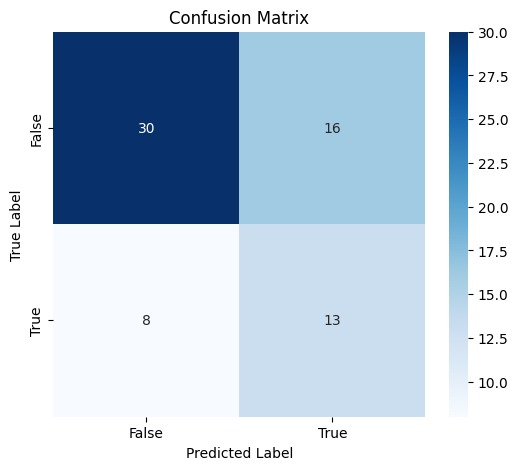

In [8]:
algorithm = "GNB"
model = build_model(X_train_mean, y_train, algorithm)

y_pred = model.predict(X_test_mean)
print("Predicted:", y_pred)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))


# --- Confusion Matrix + Heatmap ---
# (Assumes you already have y_test and y_pred defined)

# 1. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create labeled DataFrame for readability
labels = sorted(list(set(y_test)))  # auto-detect unique class labels
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 3. Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

###Tournament-Level Evaluations



####Build Predicted Bracket

#####Helper Functions

In [17]:
# ============================================================
# 1. BUILD TEAM-LEVEL SEASON STATS
# ============================================================

def build_team_stats(df):
    home_cols = [c for c in df.columns if c.startswith("home_")]
    away_cols = [c for c in df.columns if c.startswith("away_")]

    home_rename = {c: c.replace("home_", "") for c in home_cols}
    away_rename = {c: c.replace("away_", "") for c in away_cols}

    # Home stats
    home_df = df[["season"] + home_cols].rename(columns=home_rename)
    home_df["team"] = df["home_short_display_name"]

    # Away stats
    away_df = df[["season"] + away_cols].rename(columns=away_rename)
    away_df["team"] = df["away_short_display_name"]


    # Combine
    team_stats = pd.concat([home_df, away_df], ignore_index=True)

    # Average across season
    team_stats = team_stats.groupby(["season", "team"], as_index=False).mean(numeric_only=True)

    return team_stats

# ============================================================
# 2. BUILD PREDICT_FN
# ============================================================

def make_predict_fn(model, team_stats, feature_cols):
    def predict_fn(home_team, away_team, season):
        home_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == home_team)]
        away_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == away_team)]

        home_seed = int(home_row['seed'].iloc[0])
        away_seed = int(away_row['seed'].iloc[0])

        if home_seed > away_seed:
          tmp = home_row
          home_row = away_row
          away_row = tmp

        if home_row.empty or away_row.empty:
            raise ValueError(f"No stats found for home:{home_team} or away:{away_team} in season {season}")

        home_stats = home_row.drop(columns=["season","team"]).iloc[0].add_prefix("home_")
        away_stats = away_row.drop(columns=["season","team"]).iloc[0].add_prefix("away_")

        # Combine features
        row = pd.concat([home_stats, away_stats]).to_frame().T

        # Add season back if model expects it
        if "season" in model.feature_names_in_:
            row["season"] = season

        # Ensure correct order
        row = row[model.feature_names_in_]

        pred = model.predict(row)[0]

        home_name = str(home_row["team"].iloc[0])
        away_name = str(away_row["team"].iloc[0])
        print(f"{home_name} vs {away_name} ||", f"{away_name} wins" if pred == 1 else f"{home_name} wins")

        return home_name if pred == 0 else away_name

    return predict_fn


# ============================================================
# 3. BUILD AUTOMATIC BRACKET
# ============================================================

def build_bracket(df):
    """
    df must have columns: season, home_short_display_name, away_short_display_name, home_score, away_score
    Returns dict: {season: {"games_df", "incoming", "next"}}
    """
    df = df.copy().reset_index(drop=True)
    df["game_id"] = df.index.astype(int)

    results = {}

    for season, g in df.groupby("season"):
        g = g.copy().reset_index(drop=True)
        g["winner"] = g.apply(lambda r: r["home_short_display_name"] if r["home_score"]>r["away_score"] else r["away_short_display_name"], axis=1)
        g["loser"]  = g.apply(lambda r: r["away_short_display_name"] if r["home_score"]>r["away_score"] else r["home_short_display_name"], axis=1)

        # Count wins per team
        wins = g["winner"].value_counts().to_dict()
        get_wins = lambda t: wins.get(t,0)

        # Infer round = min(#wins of the two teams)+1
        # STEP 1 — Base round using win-count logic
        g["round"] = g.apply(
            lambda r: min(
                get_wins(r["home_short_display_name"]),
                get_wins(r["away_short_display_name"])
            ) + 1,
            axis=1
        )

        # STEP 2 — Explicit First Four override (round = 0)
        def is_first_four(row):
            return (
                row["home_seed"] == row["away_seed"] and
                row["home_seed"] in [11, 16]
            )

        g.loc[g.apply(is_first_four, axis=1), "round"] = 0
        #g["round"] = g.apply(lambda r: min(get_wins(r["home_short_display_name"]), get_wins(r["away_short_display_name"])) + 1, axis=1)

        # Build game linkages
        incoming_map = defaultdict(list)
        next_map = defaultdict(list)
        participants = {row["game_id"]:(row["home_short_display_name"],row["away_short_display_name"]) for _,row in g.iterrows()}
        round_lookup = defaultdict(list)
        for _,row in g.iterrows():
            round_lookup[row["round"]].append(row["game_id"])

        for _, row in g.iterrows():
            gid = row["game_id"]
            winner = row["winner"]
            curr_round = row["round"]
            next_round = curr_round + 1
            for cand_gid in round_lookup.get(next_round, []):
                h,a = participants[cand_gid]
                if winner==h or winner==a:
                    next_map[gid].append(cand_gid)
                    incoming_map[cand_gid].append(gid)

        results[season] = {"games_df": g, "incoming": dict(incoming_map), "next": dict(next_map)}

    return results

# ============================================================
# 4. SIMULATE TOURNAMENT FROM BRACKET
# ============================================================

def simulate_with_model(season_struct, season, predict_fn):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        print("=======================================")
        print(f"Round {r}:")
        print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = predict_fn(t1,t2,season)
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = predict_fn(team1,team2,season)
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = predict_fn(t1,t2,season)
            teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion


#####Building the Predicted Bracket

In [18]:
# 1. Build team stats
team_stats = build_team_stats(bracket_df).drop(columns=['score'])

# 2. Define feature columns (home_*, away_*)
feature_cols = [c for c in bracket_df.columns if c.startswith("home_") or c.startswith("away_")]
feature_cols = [c for c in feature_cols if c not in [
    "home_score", "away_score", "home_short_display_name", "away_short_display_name"
]]

algorithm = "ADA"
model = build_model(X_train_mean, y_train, algorithm)

# Build predict_fn
predict_fn_model = make_predict_fn(model, team_stats, feature_cols)

# Build bracket
brackets = build_bracket(bracket_df)

# Simulate
preds, tbr, champ = simulate_with_model(brackets[test_year], test_year, predict_fn_model)
print("Champion:", champ)

Round 1:
Alabama vs Texas A&M-CC || Alabama wins
Arizona vs Princeton || Arizona wins
Arkansas vs Illinois || Illinois wins
Baylor vs UCSB || Baylor wins
Creighton vs NC State || Creighton wins
Duke vs Oral Roberts || Duke wins
Gonzaga vs Grand Canyon || Gonzaga wins
Houston vs N Kentucky || Houston wins
Indiana vs Kent State || Indiana wins
Iowa vs Auburn || Auburn wins
Iowa State vs Pitt || Pitt wins
Kansas vs Howard || Kansas wins
Kansas St vs Montana St || Kansas St wins
Kentucky vs Providence || Kentucky wins
Marquette vs Vermont || Marquette wins
Maryland vs West Virginia || West Virginia wins
Memphis vs FAU || FAU wins
Miami vs Drake || Miami wins
Michigan St vs USC || Michigan St wins
Missouri vs Utah State || Utah State wins
Northwestern vs Boise St || Northwestern wins
Purdue vs Fair Dickinson || Purdue wins
Saint Mary's vs VCU || Saint Mary's wins
San Diego St vs Charleston || San Diego St wins
TCU vs Arizona St || TCU wins
Tennessee vs Louisiana || Tennessee wins
Texas vs C

####Build Test Bracket

#####Helper Functions

In [11]:
def build_with_data(season_struct, season):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        print("=======================================")
        print(f"Round {r}:")
        print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            #print(F"LOOK HERE: {row["winner"]}")
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = row["winner"]
                print(pred_winner[gid])
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = row["winner"]
                    print(pred_winner[gid])
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = row["winner"]
                    print(pred_winner[gid])
            teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion

#####Building the Test Bracket

In [12]:
test_bracket_df = bracket_df.query(f"season == {test_year}")

test_bracket = build_bracket(test_bracket_df)[test_year]
test_preds, test_tbr, test_champ = build_with_data(test_bracket, test_year)

Round 1:
Alabama
Princeton
Arkansas
Baylor
Creighton
Duke
Gonzaga
Houston
Indiana
Auburn
Pitt
Kansas
Kansas St
Kentucky
Marquette
Maryland
FAU
Miami
Michigan St
Missouri
Northwestern
Fair Dickinson
Saint Mary's
San Diego St
TCU
Tennessee
Texas
Penn State
UCLA
UConn
Furman
Xavier
Round 2:
Alabama
Creighton
FAU
Gonzaga
Houston
Miami
Arkansas
Kansas St
Michigan St
Princeton
San Diego St
Tennessee
Texas
UCLA
UConn
Xavier
Round 3:
San Diego St
Creighton
Miami
Kansas St
FAU
Texas
Gonzaga
UConn
Round 4:
UConn
FAU
San Diego St
Miami
Round 5:
San Diego St
UConn
Round 6:
UConn


####Compare Predicted Bracket to Test Bracket

In [19]:
wrong = 0
total = 0

for idx in range(1, len(test_tbr)+2):
  rd = tbr[idx]
  rd_test = test_tbr[idx]

  for team in rd:
    if team not in rd_test:
      wrong += 1
    total += 1
  print(f"Accuracy after Round {idx} of the tournament:")
  print(f"{(total - wrong)}/{total} = {(total-wrong)/total}")

final_acc = (total - wrong)/total
print(f"Tournament Level Accuracy: {final_acc}")

Accuracy after Round 1 of the tournament:
25/32 = 0.78125
Accuracy after Round 2 of the tournament:
35/48 = 0.7291666666666666
Accuracy after Round 3 of the tournament:
37/56 = 0.6607142857142857
Accuracy after Round 4 of the tournament:
38/60 = 0.6333333333333333
Accuracy after Round 5 of the tournament:
39/62 = 0.6290322580645161
Accuracy after Round 6 of the tournament:
40/63 = 0.6349206349206349
Accuracy after Round 7 of the tournament:
40/63 = 0.6349206349206349
Accuracy after Round 8 of the tournament:
40/63 = 0.6349206349206349
Accuracy after Round 9 of the tournament:
40/63 = 0.6349206349206349
Tournament Level Accuracy: 0.6349206349206349


##Interpretability

###Naive Bayes

away_SRS: -3.932267339038292
away_SOS: -2.8955500927026945
home_seed: -1.4019935033150897
home_SOS: 1.0546652649846306
home_Tm.: 1.335505940461914
away_seed: 1.3910915320606954
home_ORtg: 1.5003513825845545
home_SRS: 2.987873225648528


<Axes: >

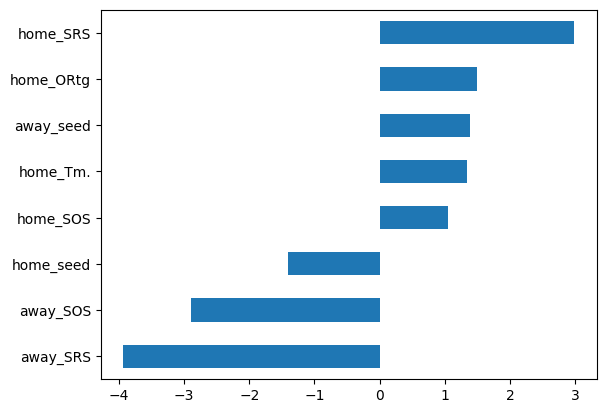

In [20]:
model = GaussianNB()
model.fit(X_train_mean, y_train)

# Compute differences
diffs = pd.Series(model.theta_[0] - model.theta_[1], index=X_train_mean.columns)

# Filter to only features where |value| > 1
diffs_filtered = diffs[diffs.abs() > 1].sort_values()

# Optional: print them
for feature, val in diffs_filtered.items():
    print(f"{feature}: {val}")

# Plot filtered series
diffs_filtered.plot.barh()


###AdaBoost



####Build the AdaBoost Model

In [21]:
model = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, estimator=DecisionTreeClassifier(max_depth=1), random_state=72)
model.fit(X_train_mean, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200, random_state=72)

####Feature Importance
This metric measures how important the AdaBoost classifier believes each feature is

<Axes: >

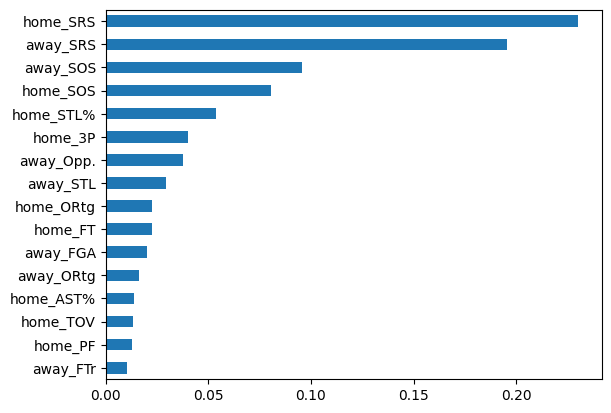

In [22]:
# Access feature importance
importances = pd.Series(model.feature_importances_, index=X_train_mean.columns).sort_values(ascending=False)

imps_filtered = importances[importances > 0.01].sort_values()
# Plot
imps_filtered.plot.barh()

####Permutation Importance
This metric measures how important each feature actually is by measuring how much the performance is impacted by turning the data in each feature into noise (This should take about 2 mins to run).

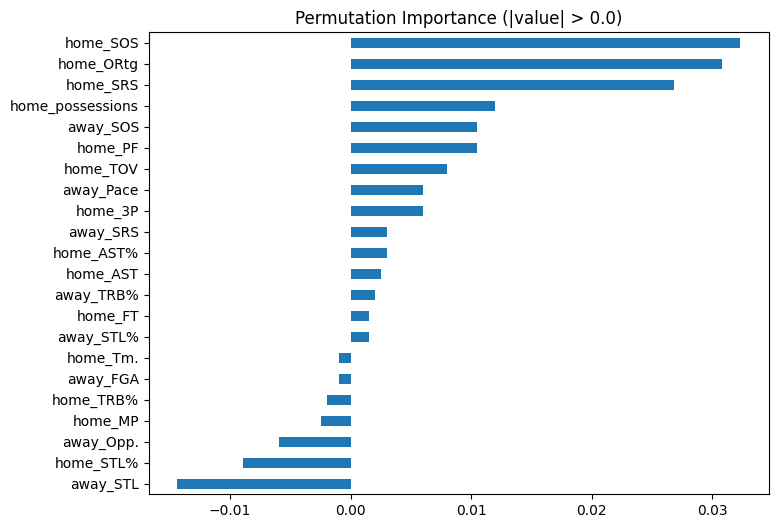

In [23]:
# Compute permutation importance
perm = permutation_importance(model, X_test_mean, y_test, n_repeats=30)

# Convert to Series
pi = pd.Series(perm.importances_mean, index=X_test_mean.columns)

# --- FILTER BY THRESHOLD ---
threshold = 0.00     # <--- set whatever threshold you want
pi_filtered = pi[pi.abs() > threshold]

# Sort & plot
pi_filtered.sort_values().plot.barh(figsize=(8,6))
plt.title(f"Permutation Importance (|value| > {threshold})")
plt.show()

#DATA VIZ

##Label Distribution

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


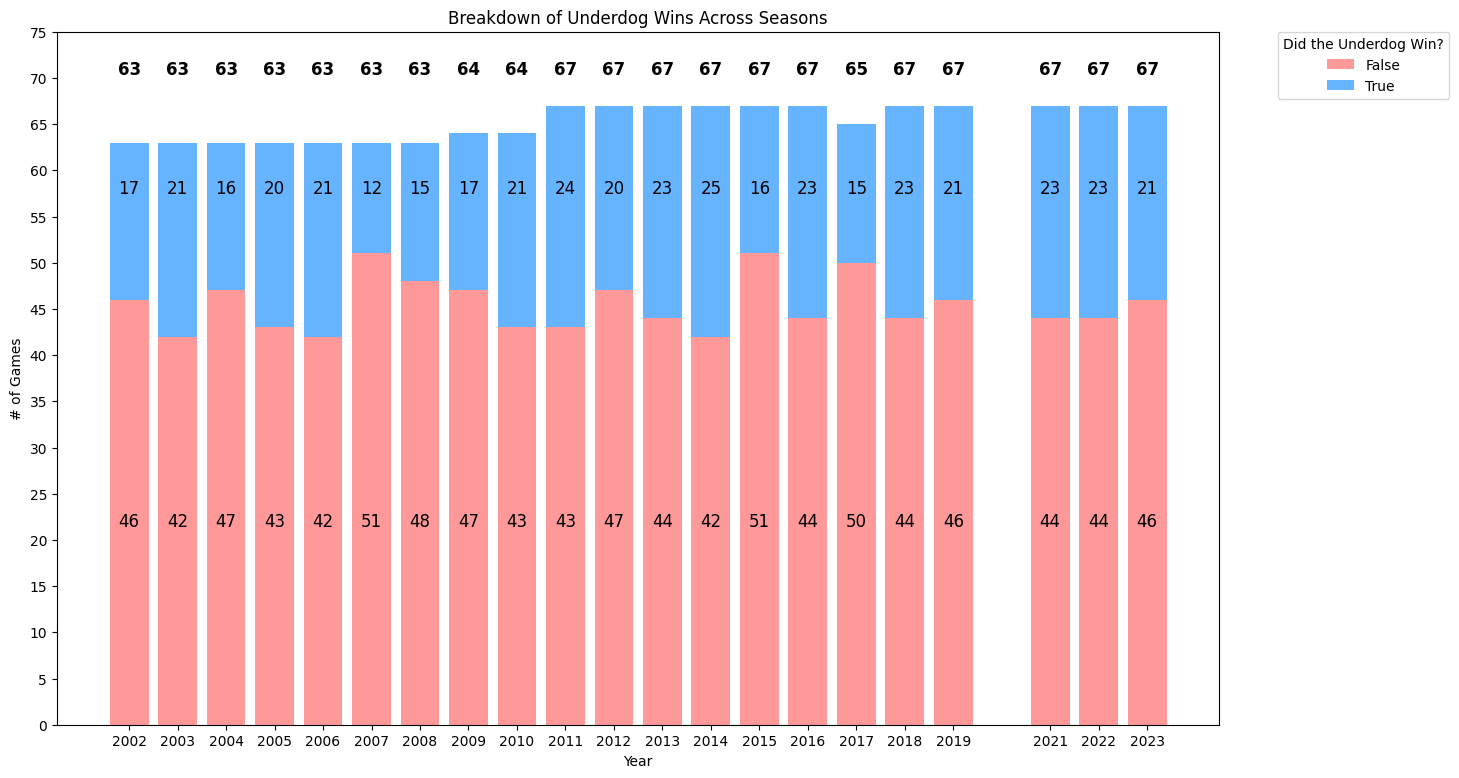

In [4]:
df = pd.read_excel("all_years.xlsx")
counts = df.groupby(['season', 'underdog_winner']).size().unstack(fill_value=0)

years = sorted([int(year) for year in df['season'].unique()])

# Extract counts
false_counts = counts[False]
true_counts = counts[True]
totals = false_counts + true_counts

plt.figure(figsize=(15, 9))

# Plot stacked bars
bar1 = plt.bar(years, false_counts, label='False', color='#ff9999')
bar2 = plt.bar(years, true_counts, bottom=false_counts, label='True', color='#66b3ff')

# 🔹 Manually fix y positions for text
y_false = 22   # height for all "False" labels
y_true  = 58   # height for all "True" labels
y_total = 70   # height for all totals

# Add each set of labels at fixed y positions
for x, f, t, total in zip(years, false_counts, true_counts, totals):
    plt.text(x, y_false, str(f), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_true, str(t), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_total, str(total), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel('Year')
plt.xticks(years)
plt.ylabel('# of Games')
plt.yticks(range(0, 79, 5))
plt.title('Breakdown of Underdog Wins Across Seasons')
plt.legend(title='Did the Underdog Win?', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.rcParams.update({
    'font.size': 21,
    'axes.titlesize': 24,
    'axes.labelsize': 21,
    'xtick.labelsize': 10,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

plt.show()
